In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import exp1
from scipy.fft import fft,ifft,fft2, ifft2, fftfreq, fftshift, ifftshift

# Given constants
xc = 0.5
yc = 0.5
sigma = 0.05

# Set up grid
N = 64
h = 1/N
x = np.linspace(0,1,N)
y = np.linspace(0,1,N)


# Define functions
def rho(x, y):
    C = 2*np.pi*sigma**2
    arg = -1/(2*sigma**2) * ((x - xc)**2 + (y - yc)**2)
    return 1/C * np.exp(arg)

def G(x, y):
    return -1/(4*np.pi) * np.log( x**2 + y**2 + h**2 )

def inf_norm(Vh, V):
    errs = np.abs(Vh - V)
    return np.amax(errs)

In [2]:
# METHOD 0: Exact solution
V0 = np.zeros([N,N])
for i in range(N):
    x_i = x[i]
    for j in range(N):
        y_j = y[j]
        arg = ( (x_i - xc)**2 + (y_j - yc)**2 + h**2)/(2*sigma**2)
        V0[i][j] = -1/(4*np.pi) * ( exp1(arg) + np.log( (x_i - xc)**2 + (y_j - yc)**2 + h**2) )

print('Method 0 complete.')

Method 0 complete.


In [10]:
# SLOW METHOD 1: Direct integration
V1 = np.zeros([N,N])
for i in range(N):
    x_i = x[i]
    for j in range(N):
        y_j = y[j]
        for ip in range(N):
            x_ip = x[ip] 
            for jp in range(N):
                y_jp = y[jp]
                V1[i][j] += rho(x_ip,y_jp) * G(x_i - x_ip, y_j - y_jp)
        V1[i][j] = h**2 * V1[i][j]

print('Slow Method 1 complete.')

Complete.


In [4]:
# FAST METHOD 1: Direct integration
V1 = np.zeros((N,N))

X,Y = np.meshgrid(x,y, indexing='ij')
rho_vals = rho(X,Y)

for i in range(N):
    for j in range(N):
        V1[i,j] = np.sum( rho_vals * G(x[i]-X,y[j]-Y) )

V1 = V1 * h**2

print('Fast Method 1 complete')

Fast Method 1 complete


In [5]:
# METHOD 2: Fourier method
V2 = np.zeros([2*N,2*N])
V2_hat = np.zeros([2*N,2*N])
rho_vals = np.zeros([2*N,2*N])
G_vals = np.zeros([2*N,2*N])

x_fft = fftfreq(2*N,h)
y_fft = x_fft

rho_vals[:N,:N] = rho(X,Y)
rho_hat = fft2(rho_vals)

G_temp = G(X,Y)
G_vals[:N,:N] = G_temp
G_vals[N:,:N] = np.flip(G_temp,axis=0)
G_vals[:N,N:] = np.flip(G_temp,axis=1)
G_vals[N:,N:] = np.flip(np.flip(G_temp,axis=0),axis=1)
G_hat = fft2(G_vals)

V2_hat = rho_hat * G_hat
V2 = ifft2(V2_hat)

x_fft = fftshift(x_fft)
y_fft = fftshift(y_fft)

x_ = (x_fft - x_fft.min()) / (x_fft.max() - x_fft.min()) * 2
y_ = (y_fft - y_fft.min()) / (y_fft.max() - y_fft.min()) * 2

print('Method 2 complete.')

Method 2 complete.


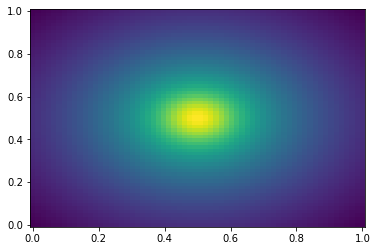

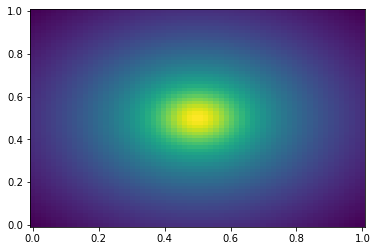

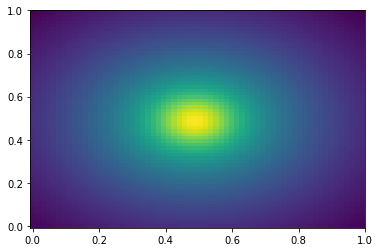

In [6]:
plt.figure()
plt.pcolormesh(x,y, V0, shading='auto')

plt.figure()
plt.pcolormesh(x,y, V1, shading='auto')

plt.figure()
plt.pcolormesh(x_[:N],y_[:N], np.real(V2[:N,:N]), shading='auto')

plt.show()

In [7]:
err = inf_norm(V1,V0)
print(err)

print(inf_norm(np.real(V2[:N,:N]),V0))

0.023716585576102678
1912.2405625844194
